In [197]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [198]:
df=pd.read_csv("winequality_red.csv")

In [199]:
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

In [200]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()

In [201]:
X_scaled=sc.fit_transform(X)

In [202]:
from sklearn.decomposition import PCA
pca=PCA(n_components=2)

In [203]:
X_pca=pca.fit_transform(X_scaled)

In [204]:
from sklearn.cluster import DBSCAN
db = DBSCAN(eps=0.5, min_samples=5)
db_cl= db.fit_predict(X_scaled)

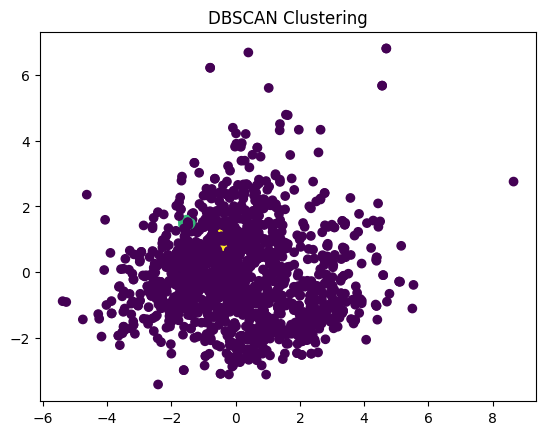

In [205]:
plt.scatter(X_pca[:,0],X_pca[:,1],c=db_cl)
plt.title("DBSCAN Clustering")
plt.show()

In [206]:
from sklearn.metrics import silhouette_score,davies_bouldin_score,adjusted_rand_score,adjusted_mutual_info_score,normalized_mutual_info_score,homogeneity_score,completeness_score,v_measure_score
print("DBSCAN Silhouette:", silhouette_score(X_scaled, db_cl))
print("DBSCAN DB Index:", davies_bouldin_score(X_scaled, db_cl))
print("DBSCAN ARI:", adjusted_rand_score(y, db_cl))
print("DBSCAN NMI:", normalized_mutual_info_score(y, db_cl))
print("DBSCAN Homogeneity:", homogeneity_score(y, db_cl))
print("DBSCAN Completeness:", completeness_score(y, db_cl))
print("DBSCAN V-measure:", v_measure_score(y, db_cl))

DBSCAN Silhouette: -0.25051192044620596
DBSCAN DB Index: 1.4123746458057294
DBSCAN ARI: -0.004378282038727852
DBSCAN NMI: 0.010806788758653763
DBSCAN Homogeneity: 0.00578366956501361
DBSCAN Completeness: 0.0821811382802757
DBSCAN V-measure: 0.010806788758653764


In [207]:
from sklearn.cluster import KMeans
km=KMeans(n_clusters=5,random_state=42)
km_cl=km.fit_predict(X_scaled)

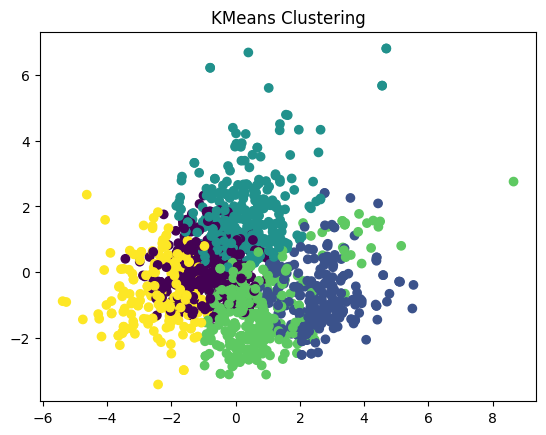

In [208]:
plt.scatter(X_pca[:,0], X_pca[:,1], c=km_cl)
plt.title("KMeans Clustering")
plt.show()

In [209]:
print("KMeans Silhouette:", silhouette_score(X_scaled, km_cl))
print("KMeans DB Index:", davies_bouldin_score(X_scaled, km_cl))
print("KMeans ARI:", adjusted_rand_score(y, km_cl))
print("KMeans NMI:", normalized_mutual_info_score(y, km_cl))
print("KMeans Homogeneity:", homogeneity_score(y, km_cl))
print("KMeans Completeness:", completeness_score(y, km_cl))
print("KMeans V-measure:", v_measure_score(y, km_cl))

KMeans Silhouette: 0.16546359497348295
KMeans DB Index: 1.7417718631616708
KMeans ARI: 0.07108299331216332
KMeans NMI: 0.09358358793532905
KMeans Homogeneity: 0.10837342172818769
KMeans Completeness: 0.08234577430781923
KMeans V-measure: 0.09358358793532905


In [210]:
from sklearn.cluster import AgglomerativeClustering
hc=AgglomerativeClustering(n_clusters=5)
hc_cl=hc.fit_predict(X_scaled)

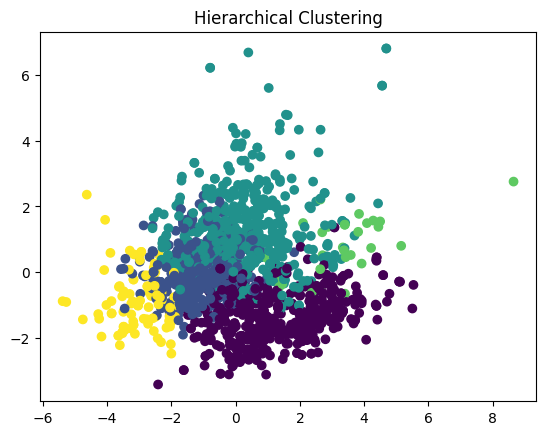

In [211]:
plt.scatter(X_pca[:,0], X_pca[:,1], c=hc_cl)
plt.title("Hierarchical Clustering")
plt.show()

In [212]:
print("Hierarchical Silhouette:", silhouette_score(X_scaled, hc_cl))
print("Hierarchical DB Index:", davies_bouldin_score(X_scaled, hc_cl))
print("Hierarchical ARI:", adjusted_rand_score(y, hc_cl))
print("Hierarchical NMI:", normalized_mutual_info_score(y, hc_cl))
print("Hierarchical Homogeneity:", homogeneity_score(y, hc_cl))
print("Hierarchical Completeness:", completeness_score(y, hc_cl))
print("Hierarchical V-measure:", v_measure_score(y, hc_cl))

Hierarchical Silhouette: 0.15447559894430443
Hierarchical DB Index: 1.5638351033089033
Hierarchical ARI: 0.05607546946527563
Hierarchical NMI: 0.08027416111924197
Hierarchical Homogeneity: 0.0854483137613215
Hierarchical Completeness: 0.07569085215260084
Hierarchical V-measure: 0.08027416111924197


In [213]:
from sklearn.neighbors import NearestNeighbors
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)

distances, indices = neighbors_fit.kneighbors(X_scaled)

In [214]:
distances = np.sort(distances[:,4])

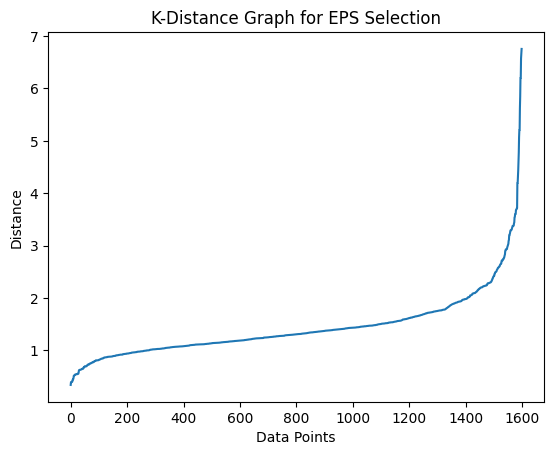

In [215]:
plt.plot(distances)
plt.title("K-Distance Graph for EPS Selection")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

In [216]:
from sklearn.cluster import DBSCAN
db=DBSCAN(eps=2,min_samples=4)
db_cl=db.fit_predict(X_scaled)

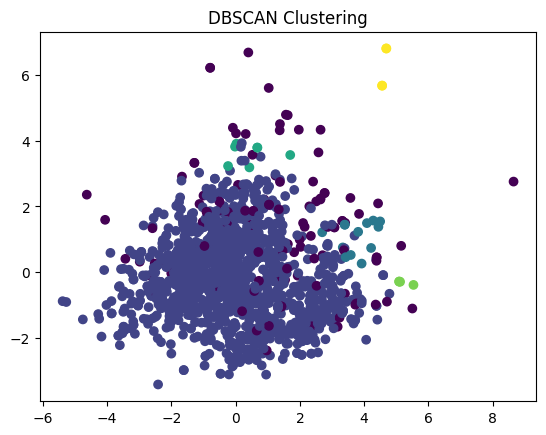

In [217]:
plt.scatter(X_pca[:,0],X_pca[:,1],c=db_cl)
plt.title("DBSCAN Clustering")
plt.show()

In [218]:
print("DBSCAN Silhouette:", silhouette_score(X_scaled, db_cl))
print("DBSCAN DB Index:", davies_bouldin_score(X_scaled, db_cl))
print("DBSCAN ARI:", adjusted_rand_score(y, db_cl))
print("DBSCAN NMI:", normalized_mutual_info_score(y, db_cl))
print("DBSCAN Homogeneity:", homogeneity_score(y, db_cl))
print("DBSCAN Completeness:", completeness_score(y, db_cl))
print("DBSCAN V-measure:", v_measure_score(y, db_cl))

DBSCAN Silhouette: 0.2298246239529028
DBSCAN DB Index: 1.7202883232463222
DBSCAN ARI: 0.006591248304144871
DBSCAN NMI: 0.015252469713726331
DBSCAN Homogeneity: 0.009981751269870639
DBSCAN Completeness: 0.03231698112841131
DBSCAN V-measure: 0.015252469713726331
